In [1]:
from typing import Annotated, Sequence, TypedDict, Literal, Optional
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage, RemoveMessage
from enum import Enum
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from settings import Settings
from rag.loader import load_vectorstore
from langchain_core.tools import tool
from langchain.agents import create_agent
from langgraph.checkpoint.sqlite import SqliteSaver

In [9]:
#суммаризация, оставим на потом
def summarize_history(messages: list) -> str:
    all_text = ""
    for message in messages:
        message_type = "Human" if isinstance(message, HumanMessage) else "Agent"
        all_text += f"{message_type}: {message.content} \n"
    response = llm.invoke([
        SystemMessage(content="Сожми диалог, выделив ключевые события и договоренности"),
        HumanMessage(content=f"Суммаризируй:\n{all_text}")
    ])
    return response.content

def summary_node(state: AgentState) -> dict:
    messages = state["messages"]
    last_message = messages[-1]

    if len(messages) > settings.max_history_messages:
        summary = summarize_history(messages[:-1])
        remove_old = [RemoveMessage(id=m.id) for m in messages[:-1]]
        summary_message = SystemMessage(content=f"Сводка предыдущих событий: {summary}")
        result = manager.invoke({"history": summary, "query": last_message})
        return {
            "messages": remove_old + [summary_message, AIMessage(content=result.content)]
        }
    else:
        result = manager.invoke({"history": messages, "query": last_message})
        return {
            "messages": [AIMessage(content=result.content)]
            }

In [2]:
from nodes.agent_state import AgentState, llm
from nodes.router import router_node, route_after_router
from nodes.lawyer import lawyer_node
from nodes.finance import financial_node
from nodes.property import property_manager_node, tenant_extractor_node
from nodes.assistant import assistant_node
from nodes.work_talk import work_small_talk_node, route_work_small_talk
from nodes.combiner import combiner_node
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.sqlite import SqliteSaver
from settings import Settings

settings = Settings()

In [3]:
builder = StateGraph(AgentState)

builder.add_node("work_small_talk_node", work_small_talk_node)
builder.add_node("router_node", router_node)
builder.add_node("lawyer_node", lawyer_node)
builder.add_node("financial_node", financial_node)
builder.add_node("tenant_extractor_node", tenant_extractor_node)
builder.add_node("property_manager_node", property_manager_node)
builder.add_node("assistant_node", assistant_node)
builder.add_node("combiner_node", combiner_node)

builder.add_edge(START, "work_small_talk_node")

# Send запускает ноды параллельно
builder.add_conditional_edges(
    "work_small_talk_node",
    route_work_small_talk,
    {
        "router_node": "router_node",
        "assistant_node": "assistant_node"
    }
)

builder.add_conditional_edges(
    "router_node",
    route_after_router,
    {
        "lawyer_node": "lawyer_node",
        "financial_node": "financial_node",
        "property_manager_node": "tenant_extractor_node",
    }
)

builder.add_edge("tenant_extractor_node", "property_manager_node")

builder.add_edge("lawyer_node", "combiner_node")
builder.add_edge("financial_node", "combiner_node")
builder.add_edge("property_manager_node", "combiner_node")
builder.add_edge("assistant_node", "combiner_node")
builder.add_edge("combiner_node", END)

graph = builder.compile()

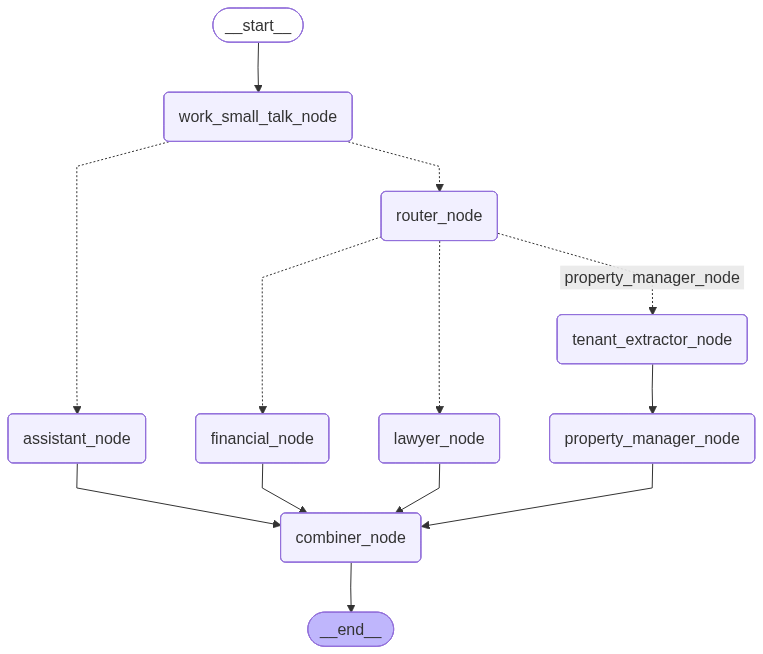

In [3]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_ascii())

# Блок тестирования Роутиинга

In [4]:
routing_tests = [
    # (запрос, ожидаемая нода)
    ("Когда заканчивается договор с Озоном?", "lawyer"),
    ("Рассчитай налог УСН за квартал, доход 500000 руб", "financial"),
    ("Когда последний раз меняли замок у Гемотеста?", "property_manager"),
    ("Как дела?", "assistant"),
    ("", "assistant"),  # fallback
]

with SqliteSaver.from_conn_string("memory.db") as checkpointer:
    graph = builder.compile(checkpointer=checkpointer)
    
    for query, expected_route in routing_tests:
        result = graph.invoke(
            {"messages": [HumanMessage(content=query)]},
            config={"configurable": {"thread_id": "test_routing"}}
        )
        status = "✅" if result["next_step"] == expected_route else "❌"
        print(f"{status} Ожидали: {expected_route}, получили: {result['next_step']}")
        print(f"   Запрос: {query}")
        print(f"   Ответ: {result["messages"][-1].content}")
        print()

lawyer_node
1 [AIMessage(content='Договор аренды № 12/2023 с ООО «Озон Логистика» заканчивается **31.01.2026** (срок: **01.02.2023 — 31.01.2026**).', additional_kwargs={}, response_metadata={}, id='06ec9659-2c2e-48d5-9ad8-00dde18e1552', tool_calls=[], invalid_tool_calls=[])]
✅ Ожидали: lawyer, получили: lawyer
   Запрос: Когда заканчивается договор с Озоном?
   Ответ: Рассчитаем налог по УСН за квартал при доходе **500 000 руб.** и ставке **6%**.  
Формула простая: **налог = доход × ставка**. Подставляем значения: **500 000 × 6% = 500 000 × 0,06 = 30 000 руб.**  
✅ **Налог УСН за квартал: 30 000 руб.**

Отдельно по объекту «Гемотест»: в текущих данных у меня нет информации, чтобы понять, когда в последний раз меняли замок. Уточните, пожалуйста:  
1) адрес/помещение «Гемотест» (или номер договора/арендатора),  
2) о каком именно замке речь (входная дверь, служебный или замок на кабинете).  

После этого смогу проверить по вашим данным и зафиксировать ответ.

financial_node
1 [AIMessage(

In [7]:
[1, 2, 3][-2:]

[2, 3]

In [12]:
result["partial_responses"][1]

'Пока в нашей истории переписки нет данных о том, когда в «Гемотесте» последний раз меняли замок (и вообще нет упоминаний по этому объекту).\n\nУточните, пожалуйста:\n1) адрес/помещение «Гемотеста» (или номер договора/арендатора),  \n2) если знаете — примерную дату или кто менял (ваша служба/подрядчик).\n\nПосле этого смогу зафиксировать запрос и проверить по вашим документам/журналам обслуживания.'

In [13]:
result["messages"]

[HumanMessage(content='Когда заканчивается договор с Озоном?', additional_kwargs={}, response_metadata={}, id='41ff7fee-0508-472f-8e7a-f8a4967e2b03'),
 AIMessage(content='Договор аренды № 12/2023 с ООО «Озон Логистика» заканчивается **31.01.2026** (срок: **01.02.2023 — 31.01.2026**).', additional_kwargs={}, response_metadata={}, id='843301a5-b9a1-48d6-a3f7-ab2ce4ccdb63', tool_calls=[], invalid_tool_calls=[]),
 AIMessage(content='Конечно. Пришлите, пожалуйста, сами ответы (текстом) или хотя бы их основные фрагменты — и я объединю их в один связный естественный текст, сохранив всю полезную информацию.', additional_kwargs={}, response_metadata={}, id='5467568d-3116-4f9a-8690-86131df048b8', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Рассчитай налог УСН за квартал, доход 500000 руб', additional_kwargs={}, response_metadata={}, id='228d5f78-7066-4c80-8bb3-2f95e8e71601'),
 AIMessage(content='Рассчитаем налог по УСН за квартал при доходе **500 000 руб.** (ставка **6%**).\n\n

In [ ]:
test_queries = [
    "Какой порог для УСН сейчас в России?",        # → lawyer
    "Рассчитай налог за квартал по объекту Озон",   # → financial
    "Когда последняя поверка счётчиков у Гемотеста?", # → property_manager
    "Как дела? Расскажи анекдот",                   # → assistant
    "Нужно ли прописать ставку НДС в договор с гемотестом или она там уже есть?" # → property_manager
]


for query in test_queries:
    result = graph.invoke({
        "messages": [HumanMessage(content=query)]
    })
    print(f"Запрос:  {query}")
    print(f"Маршрут: {result['next_step']}")
    print(f"Причина: {result['reason']}")
    print(f"Ответ:   {result['messages'][-1].content}")
    print("-" * 60)

Запрос:  Какой порог для УСН сейчас в России?
Маршрут: lawyer
Причина: Пользователь спрашивает про актуальное законодательство/порог по УСН в России.
Ответ:   В предоставленных договорах аренды **нет информации** о порогах/лимитах для УСН (ни по доходам, ни по численности, ни по стоимости ОС).

Если вам нужен ответ именно про **текущий порог УСН в России**, пришлите, пожалуйста, источник/документ, на который нужно опираться, либо уточните, какой именно порог вас интересует (по доходам, по численности, по стоимости ОС) — и я смогу ответить, но **строго на основе договоров** сейчас ответить нельзя.
------------------------------------------------------------
Запрос:  Рассчитай налог за квартал по объекту Озон
Маршрут: financial
Причина: Запрос требует расчета налога за квартал и оценки финансовых показателей по объекту (Озон), что относится к финансовым вычислениям и оптимизации.
Ответ:   Могу рассчитать, но не хватает исходных данных: по УСН налог считается от **дохода за квартал**.

По

In [45]:
query = "Какой штрфа за досрочный выезд у Вайлдбериз?"
result = graph.invoke({
        "messages": [HumanMessage(content=query)]
    })
print(result['next_step'])
print(result['reason'])
print(result['messages'][-1].content)

lawyer
Вопрос про условия договора/штрафы при досрочном выезде арендатора (Wildberries), то есть про юридические положения и прописанные в договоре пункты.
По **ДОГОВОРУ АРЕНДЫ № 3/2024** (арендатор **ООО “Вайлдберриз”**) штраф за досрочное расторжение/досрочный выезд составляет:

**6 месячных платежей.**

Размер в рублях в договоре не указан — только в количестве месячных платежей.


In [50]:
query = "Рассчитай доод по Озону за квартал и налог УСН?" \
"Площадь 450 кв. метров, ставка 1200 руб\кв.м"

result = graph.invoke({
        "messages": [HumanMessage(content=query)]
    })
print(result['next_step'])
print(result['reason'])
print(result['messages'][-1].content)

[HumanMessage(content='Рассчитай доод по Озону за квартал и налог УСН?Площадь 450 кв. метров, ставка 1200 руб\\кв.м', additional_kwargs={}, response_metadata={}, id='391977eb-932c-45bb-bc39-38bc54bc39fd'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 343, 'total_tokens': 375, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-nano-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DY8kTueecC4ZeoLmYN2gtWyyEYoP0', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dbf31-01e0-7031-96fd-a5e0fd51463a-0', tool_calls=[{'name': 'calculate_quarterly_income', 'args': {'area': 450, 'rate_per_sqm': 1200, 'months': 3}, 'id': 'call_McyxeJ8qpgp47SMxPgDSVKB5', 'ty

In [35]:
with SqliteSaver.from_conn_string("memory.db") as checkpointer:
    graph = builder.compile(checkpointer=checkpointer)

    # Имитируем историю по арендатору Гемотест
    config = {"configurable": {"thread_id": "hemotest"}}

    events = [
        "Зафиксируй: 15 января провели поверку счётчиков в помещении Гемотест",
        "Зафиксируй: 20 января Гемотест пожаловался на протечку в подсобке",
        "Зафиксируй: 25 января протечку в Гемотест устранили, подрядчик Иванов С.А.",
        "Зафиксируй: 1 февраля Гемотест заявил о желании изменить высеку",
        "Зафиксируй: 15 февраля вывеска Гемотеста была заменена",
        "Поверка счетчиков и вайлдбериз была 2 февраля",
        "Озон обновил свою вывеску 5 марта",
        "Когда была последняя поверка счётчиков у Гемотеста?"
    ]

    for event in events:
        result = graph.invoke(
            {"messages": [HumanMessage(content=event)]},
            config=config
        )
        print(f"Вопрос: {event}")
        print(f"Ответ:  {result['messages'][-1].content}")
        print("-" * 60)

property_manager_node
hemotest
hemotest 2
['Human: Зафиксируй: 15 января провели поверку счётчиков в помещении Гемотест', 'Agent: Зафиксировал в истории взаимодействия с арендаторами: **15 января** в помещении **«Гемотест»** была проведена **поверка счётчиков**.']


Вопрос: Зафиксируй: 15 января провели поверку счётчиков в помещении Гемотест
Ответ:  Зафиксировал в истории взаимодействия с арендаторами: **15 января** в помещении **«Гемотест»** была проведена **поверка счётчиков**.
------------------------------------------------------------
property_manager_node
hemotest
hemotest 4
['Human: Зафиксируй: 15 января провели поверку счётчиков в помещении Гемотест', 'Agent: Зафиксировал в истории взаимодействия с арендаторами: **15 января** в помещении **«Гемотест»** была проведена **поверка счётчиков**.', 'Human: Зафиксируй: 20 января Гемотест пожаловался на протечку в подсобке', 'Agent: Зафиксировал в истории взаимодействия с арендаторами: **20 января** арендатор **«Гемотест»** **пожаловалс

In [15]:
config = {"configurable": {"thread_id": "hemotest"}}

events = [
    "Зафиксируй: 15 января провели поверку счётчиков в помещении Гемотест",
    "Зафиксируй: 20 января Гемотест пожаловался на протечку в подсобке",
    "Зафиксируй: 25 января протечку в Гемотест устранили, подрядчик Иванов С.А.",
    "Зафиксируй: 1 февраля Гемотест заявил о желании изменить высеку",
    "Зафиксируй: 15 февраля вывеска Гемотеста была заменена",
    "Поверка счетчиков и вайлдбериз была 2 февраля",
    "Озон обновил свою вывеску 5 марта",
    "Когда была последняя поверка счётчиков у Гемотеста?"
]

for event in events:
    result = graph.invoke(
        {"messages": [HumanMessage(content=event)]},
        config=config
    )
    print(f"Вопрос: {event}")
    print(f"Ответ:  {result['messages'][-1].content}")
    print("-" * 60)

property_manager_node
hemotest
hemotest 2
['Human: Зафиксируй: 15 января провели поверку счётчиков в помещении Гемотест', 'Agent: Зафиксировал в истории взаимодействия с арендатором: **15 января** в помещении **«Гемотест»** была проведена **поверка счётчиков**.']


Вопрос: Зафиксируй: 15 января провели поверку счётчиков в помещении Гемотест
Ответ:  Зафиксировал в истории взаимодействия с арендатором: **15 января** в помещении **«Гемотест»** была проведена **поверка счётчиков**.
------------------------------------------------------------
property_manager_node
hemotest
hemotest 2
['Human: Зафиксируй: 20 января Гемотест пожаловался на протечку в подсобке', 'Agent: Зафиксировал в истории взаимодействия с арендаторами:\n\n**20 января:** Гемотест пожаловался на **протечку в подсобке**.']


Вопрос: Зафиксируй: 20 января Гемотест пожаловался на протечку в подсобке
Ответ:  Зафиксировал в истории взаимодействия с арендаторами:

**20 января:** Гемотест пожаловался на **протечку в подсобке**.
---

KeyboardInterrupt: 

In [ ]:
#при запуске с 0 память подтягиваается
with SqliteSaver.from_conn_string("memory.db") as checkpointer:
    graph = builder.compile(checkpointer=checkpointer)

    # Имитируем историю по арендатору Гемотест
    config = {"configurable": {"thread_id": "hemotest"}}

    events = [
        "Когда была последняя поверка счётчиков у Гемотеста?",
    ]

    for event in events:
        result = graph.invoke(
            {"messages": [HumanMessage(content=event)]},
            config=config
        )
        print(f"Вопрос: {event}")
        print(f"Ответ:  {result['messages'][-1].content}")
        print("-" * 60)

property_manager_node
Вопрос: Когда была последняя поверка счётчиков у Гемотеста?
Ответ:  Последняя поверка счётчиков у **«Гемотеста»** была **15 января**.
------------------------------------------------------------
